# Librerias


In [1]:
# importing packages
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import json

In [2]:
pip install seaborn

In [3]:
pip install vapeplot

# Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import sys
sys.path.append('/content/drive/MyDrive/Results_Analysis/Notebooks')

In [6]:
from chargers import *
from metrics import *
from graphs import *

In [7]:
notebooks_route = "/content/drive/My Drive/Results_Analysis/Notebooks/"

In [8]:
experiment = "presidential" # presidential, plebiscite, or abortion
column_to_predict = 'elec_pres_144_a'

In [9]:
results_route =  f"/content/drive/My Drive/Results_Analysis/results_dataframes/{experiment}/"
prompt_design_route =  f"/content/drive/My Drive/Results_Analysis/results_dataframes/{experiment}/Prompt Design Variations/"

# Dataframes Upload

In [10]:
d = {
    "boric" : 1,
    "kast" : 2,
    "nulo": 3,
    "gabriel boric font":1,
    "josé antonio kast rist":2,
    "null":3,
    "none":3,
    "neither":3,
    "voted null": 3,
}

## Original Prompt Dataframes

In [11]:
gpt3_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_cot.csv")
gpt3_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_json_df, d, prompt_type='cot')
gpt4_json_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt4_cot.csv")
gpt4_json = data_charger(results_route +"exp_inputs_filtrado.csv", gpt4_json_df, d, prompt_type='cot')
llama_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_cot.jsonl", d, prompt_type='cot')
mistral_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_cot.jsonl", d, prompt_type='cot')
t0_json = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_t0_cot.jsonl", d, prompt_type='cot', is_t0=True)

## Spanish Prompt Dataframes

In [12]:
gpt3_json_esp_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_cot_spanish.csv")
gpt3_json_esp = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_json_esp_df, d, language='esp', prompt_type='cot')
llama_json_esp = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_llama_cot_spanish.jsonl", d, language='esp', prompt_type='cot')
mistral_json_esp = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +f"{experiment}_chile_mistral_cot_spanish.jsonl", d, language='esp', prompt_type='cot')

## Zero-shot Dataframes

In [13]:
gpt3_json_0_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_cot_zeroshot.csv")
gpt3_json_0 = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_json_0_df, d, prompt_type='cot')
llama_json_0 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_cot_zeroshot.jsonl", d, prompt_type='cot')
mistral_json_0 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_cot_zeroshot.jsonl", d, prompt_type='cot')

## Prompt With Context Dataframes

In [14]:
gpt3_json_context_df = pd.read_csv(results_route + f"{experiment}_chile_chatgpt3_cot_with_context.csv")
gpt3_json_context = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_json_context_df, d, prompt_type='cot')
llama_json_context = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_llama_cot_with_context.jsonl", d, prompt_type='cot')
mistral_json_context = data_charger(results_route + "exp_inputs_filtrado.csv", results_route + f"{experiment}_chile_mistral_cot_with_context.jsonl", d, prompt_type='cot')

## Prompt Design Dataframes

In [15]:
gpt3_list_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_list.csv")
gpt3_list = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_list_df, d)
llama_list = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_list.jsonl", d)
mistral_list = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_list.jsonl", d)
t0_list = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_list.jsonl", d)

In [16]:
gpt3_text_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_text.csv")
gpt3_text = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_text_df, d)
llama_text = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_text.jsonl", d)
mistral_text = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_text.jsonl", d)
t0_text = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_text.jsonl", d)

In [17]:
gpt3_refpaper_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_refpaper.csv")
gpt3_refpaper = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_refpaper_df, d)
llama_refpaper = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_refpaper.jsonl", d)
mistral_refpaper = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_refpaper.jsonl", d)
t0_refpaper = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_refpaper.jsonl", d)

In [18]:
gpt3_text_with_preamble_df = pd.read_csv(prompt_design_route + f"{experiment}_chile_chatgpt3_text_with_preamble.csv")
gpt3_text_with_preamble = data_charger(results_route +"exp_inputs_filtrado.csv", gpt3_text_with_preamble_df, d)
llama_text_with_preamble = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_llama_text_with_preamble.jsonl", d)
mistral_text_with_preamble = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_mistral_text_with_preamble.jsonl", d)
t0_text_with_preamble = data_charger(results_route + "exp_inputs_filtrado.csv", prompt_design_route + f"{experiment}_chile_t0_text_with_preamble.jsonl", d)

## Finetuning Dataframes

In [19]:
f_1 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +"presidential_chile_f1_cot.jsonl", d, prompt_type='cot')
f_2 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +"presidential_chile_f2_cot.jsonl", d, prompt_type='cot')
f_3 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +"presidential_chile_f3_cot.jsonl", d, prompt_type='cot')
f_4 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +"presidential_chile_f4_cot.jsonl", d, prompt_type='cot')
f_5 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +"presidential_chile_f5_cot.jsonl", d, prompt_type='cot')
f_6 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +"presidential_chile_f6_cot.jsonl", d, prompt_type='cot')
f_7 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +"presidential_chile_f7_cot.jsonl", d, prompt_type='cot')
f_8 = data_charger(results_route +"exp_inputs_filtrado.csv", results_route +"presidential_chile_f8_cot.jsonl", d, prompt_type='cot')

#f_7 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", results_route +"elecpresf_1000_1e4_0001_1_json_inverted_final_rfs0.jsonl", d)
#f_8 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", results_route +"elecpresf1000_1e4_01_1_json_inverted_final_rfs0.jsonl", d)

In [20]:
#f_1 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", ruta_resultados_analisis +"elecpresf_10000_1e6_01_1_json_inverted_final_rfs0.jsonl", d)
#f_2 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", ruta_resultados_analisis +"elecpresf_5000_1e6_01_1_json_inverted_final_rfs0.jsonl", d)
#f_3 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", ruta_resultados_analisis +"elecpresf_5000_1e6_0.001_1_json_inverted_final_rfs0.jsonl", d)
#f_4 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", ruta_resultados_analisis +"elecpresf_5000_1e4_0.001_1_json_inverted_final_rfs0.jsonl", d)
#f_5 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", ruta_resultados_analisis +"elecpresf_1000_1e6_01_1_json_inverted_final_rfs0.jsonl", d)
#f_6 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", ruta_resultados_analisis +"elecpresf_1000_1e6_0001_1_json_inverted_final_rfs0.jsonl", d)
#f_7 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", ruta_resultados_analisis +"elecpresf_1000_1e4_0001_1_json_inverted_final_rfs0.jsonl", d)
#f_8 = llama_finetuned_charger_eng_inverted(ruta +"exp_inputs_filtrado.csv", ruta_resultados_analisis +"elecpresf1000_1e4_01_1_json_inverted_final_rfs0.jsonl", d)

# Models and Prompt Analysis Metrics By Sociodemographic Groups

## Random Forest

In [21]:
# load dataset
df_rf = pd.read_csv(results_route + "randomforest_presidential_chile.csv")
df_rf

,Unnamed: 0,sexo,edad,zona_u_r,gse,esc_nivel_1,info_enc_58,info_enc_30,religion_82,iden_pol_2,...,region_LOS LAGOS,region_LOS RÍOS,region_MAGALLANES,region_MAULE,region_METROPOLITANA,region_TARAPACÁ,region_VALPARAÍSO,region_ÑUBLE,elec_pres_144_a,pred
0,0,2,40,1,3,3,2,0.0,9,8,...,0,0,0,0,1,0,0,0,1.0,1.0
1,1,2,54,1,3,6,2,0.0,1,5,...,0,0,0,0,0,0,1,0,0.0,0.0
2,2,2,39,1,2,8,2,0.0,1,10,...,0,0,0,1,0,0,0,0,1.0,1.0
3,3,1,21,1,2,7,2,0.0,1,6,...,0,0,0,1,0,0,0,0,0.0,0.0
4,4,2,19,1,2,4,2,0.0,9,6,...,0,0,0,0,1,0,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,655,2,25,1,3,6,1,5.0,10,5,...,0,0,0,0,0,0,1,0,0.0,0.0
656,656,2,25,1,1,8,2,0.0,99,6,...,0,0,0,0,1,0,0,0,1.0,1.0
657,657,2,22,1,4,7,2,0.0,1,99,...,0,0,0,0,1,0,0,0,0.0,0.0
658,658,1,54,1,1,8,2,0.0,1,5,...,0,0,0,0,0,0,0,1,0.0,0.0


In [22]:
# Identificar las columnas de región
region_columns = [col for col in df_rf.columns if col.startswith('region_')]

# Reconstruir la columna original 'nom_region'
df_rf['nom_region'] = df_rf[region_columns].idxmax(axis=1).str.replace('region_', '')

results_rf = metrics_dataset_gen_chile(df_rf, column_to_predict)
results_rf

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.137032,0.883117,0.872926,0.862968
1,Man,0.113582,0.916364,0.901142,0.886418
2,Young adult,0.058727,0.948718,0.944981,0.941273
3,Adult,0.099494,0.912145,0.906288,0.900506
4,Senior adult,0.189948,0.846154,0.827709,0.810052
5,Metropolitan region,0.191079,0.871528,0.839058,0.808921
6,Other region,0.092096,0.916667,0.912264,0.907904
7,Indigenous people,0.076346,0.982759,0.952290,0.923654
8,Non-indigenous people,0.131888,0.887960,0.877924,0.868112
9,None (indigenous),0.000000,1.000000,1.000000,1.000000


## JSON

In [23]:
gpt3_json_metrics = metrics_dataset_gen_chile(gpt3_json, column_to_predict)
gpt3_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.057563,0.607792,0.738995,0.942437
1,Man,0.083553,0.687273,0.785485,0.916447
2,Young adult,0.100926,0.717949,0.798367,0.899074
3,Adult,0.078168,0.658915,0.768509,0.921832
4,Senior adult,0.048762,0.574359,0.716247,0.951238
5,Metropolitan region,0.044108,0.690972,0.802124,0.955892
6,Other region,0.074302,0.602151,0.729666,0.925698
7,Indigenous people,0.144385,0.637931,0.730909,0.855615
8,Non-indigenous people,0.056068,0.643813,0.765508,0.943932
9,None (indigenous),0.627021,0.250000,0.299351,0.372979


In [24]:
gpt4_json_metrics = metrics_dataset_gen_chile(gpt4_json, column_to_predict)
gpt4_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.089268,0.587013,0.713889,0.910732
1,Man,0.088559,0.716364,0.802213,0.911441
2,Young adult,0.111721,0.717949,0.794083,0.888279
3,Adult,0.085833,0.661499,0.767574,0.914167
4,Senior adult,0.095021,0.569231,0.698872,0.904979
5,Metropolitan region,0.057066,0.680556,0.790543,0.942934
6,Other region,0.103438,0.610215,0.726180,0.896562
7,Indigenous people,0.228429,0.637931,0.698416,0.771571
8,Non-indigenous people,0.078741,0.642140,0.756784,0.921259
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [25]:
llama_json_metrics = metrics_dataset_gen_chile(llama_json, column_to_predict)
llama_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.126456,0.646753,0.743233,0.873544
1,Man,0.068130,0.745455,0.828303,0.931870
2,Young adult,0.118532,0.782051,0.828789,0.881468
3,Adult,0.103568,0.702842,0.787920,0.896432
4,Senior adult,0.124047,0.620513,0.726432,0.875953
5,Metropolitan region,0.104186,0.732639,0.806051,0.895814
6,Other region,0.101125,0.653226,0.756611,0.898875
7,Indigenous people,0.149879,0.706897,0.771921,0.850121
8,Non-indigenous people,0.104381,0.687291,0.777746,0.895619
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [26]:
mistral_json_metrics = metrics_dataset_gen_chile(mistral_json, column_to_predict)
mistral_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.207014,0.498701,0.612320,0.792986
1,Man,0.240521,0.592727,0.665821,0.759479
2,Young adult,0.284431,0.615385,0.661706,0.715569
3,Adult,0.203473,0.563307,0.659918,0.796527
4,Senior adult,0.234847,0.456410,0.571765,0.765153
5,Metropolitan region,0.201338,0.565972,0.662479,0.798662
6,Other region,0.231869,0.516129,0.617406,0.768131
7,Indigenous people,0.299260,0.568966,0.628015,0.700740
8,Non-indigenous people,0.213426,0.535117,0.636925,0.786574
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [27]:
t0_json_metrics = metrics_dataset_gen_chile(t0_json, column_to_predict)
t0_json_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.685936,0.322078,0.318021,0.314064
1,Man,0.631752,0.396364,0.381789,0.368248
2,Young adult,0.776787,0.205128,0.213789,0.223213
3,Adult,0.654898,0.364341,0.354461,0.345102
4,Senior adult,0.636516,0.389744,0.376156,0.363484
5,Metropolitan region,0.667393,0.347222,0.339758,0.332607
6,Other region,0.659860,0.357527,0.348617,0.340140
7,Indigenous people,0.694678,0.310345,0.307813,0.305322
8,Non-indigenous people,0.660837,0.356187,0.347467,0.339163
9,None (indigenous),0.557923,0.500000,0.469258,0.442077


## Spanish

In [28]:
gpt3_json_esp_metrics = metrics_dataset_gen_chile(gpt3_json_esp, column_to_predict)
gpt3_json_esp_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.194445,0.563636,0.663224,0.805555
1,Man,0.142728,0.683636,0.760671,0.857272
2,Young adult,0.185315,0.679487,0.740970,0.814685
3,Adult,0.176213,0.645995,0.724138,0.823787
4,Senior adult,0.174775,0.523077,0.640296,0.825225
5,Metropolitan region,0.161901,0.635417,0.722818,0.838099
6,Other region,0.181832,0.596774,0.690151,0.818168
7,Indigenous people,0.260862,0.568966,0.642983,0.739138
8,Non-indigenous people,0.164311,0.618729,0.711027,0.835689
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [29]:
mistral_json_esp_metrics = metrics_dataset_gen_chile(mistral_json_esp, column_to_predict)
mistral_json_esp_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.326953,0.454545,0.542626,0.673047
1,Man,0.356764,0.512727,0.570614,0.643236
2,Young adult,0.361730,0.551282,0.591596,0.638270
3,Adult,0.299272,0.514212,0.593153,0.700728
4,Senior adult,0.412108,0.379487,0.461241,0.587892
5,Metropolitan region,0.288185,0.520833,0.601529,0.711815
6,Other region,0.374368,0.446237,0.520922,0.625632
7,Indigenous people,0.400048,0.465517,0.524253,0.599952
8,Non-indigenous people,0.332766,0.479933,0.558293,0.667234
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [30]:
llama_json_esp_metrics = metrics_dataset_gen_chile(llama_json_esp, column_to_predict)
llama_json_esp_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.099876,0.618182,0.732975,0.900124
1,Man,0.118811,0.676364,0.765309,0.881189
2,Young adult,0.050203,0.794872,0.865456,0.949797
3,Adult,0.136492,0.656331,0.745799,0.863508
4,Senior adult,0.068401,0.553846,0.694691,0.931599
5,Metropolitan region,0.082641,0.666667,0.772175,0.917359
6,Other region,0.113609,0.623656,0.732167,0.886391
7,Indigenous people,0.260895,0.586207,0.653836,0.739105
8,Non-indigenous people,0.084854,0.648829,0.759313,0.915146
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


## Sin fewShot

In [31]:
print(gpt3_json_0[column_to_predict].value_counts())
print(gpt3_json_0["pred"].value_counts())

elec_pres_144_a
1.0    382
2.0    233
3.0     45
Name: count, dtype: int64
pred
1    387
2    226
3     47
Name: count, dtype: int64


In [32]:
print(llama_json_0[column_to_predict].value_counts())
print(llama_json_0["pred"].value_counts())

elec_pres_144_a
1.0    382
2.0    233
3.0     45
Name: count, dtype: int64
pred
 1    516
 2    121
-1     23
Name: count, dtype: int64


In [33]:
print(mistral_json_0[column_to_predict].value_counts())
print(mistral_json_0["pred"].value_counts())

elec_pres_144_a
1.0    382
2.0    233
3.0     45
Name: count, dtype: int64
pred
 3    326
 1    182
 2    150
-1      2
Name: count, dtype: int64


In [34]:
gpt_json_metrics_0 = metrics_dataset_gen_chile(gpt3_json_0, column_to_predict)
gpt_json_metrics_0

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.015779,0.615584,0.757431,0.984221
1,Man,0.041528,0.716364,0.819919,0.958472
2,Young adult,0.063214,0.756410,0.836991,0.936786
3,Adult,0.031649,0.671835,0.793290,0.968351
4,Senior adult,0.029269,0.589744,0.733729,0.970731
5,Metropolitan region,0.039670,0.701389,0.810684,0.960330
6,Other region,0.040289,0.623656,0.756021,0.959711
7,Indigenous people,0.129454,0.637931,0.736303,0.870546
8,Non-indigenous people,0.002917,0.660535,0.794644,0.997083
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [35]:
llama_json_metrics_0 = metrics_dataset_gen_chile(llama_json_0, column_to_predict)
llama_json_metrics_0

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.290819,0.649351,0.677948,0.709181
1,Man,0.280797,0.698182,0.708537,0.719203
2,Young adult,0.215421,0.769231,0.776829,0.784579
3,Adult,0.290754,0.671835,0.690034,0.709246
4,Senior adult,0.308955,0.625641,0.656719,0.691045
5,Metropolitan region,0.297205,0.690972,0.696834,0.702795
6,Other region,0.278519,0.653226,0.685659,0.721481
7,Indigenous people,0.313077,0.689655,0.688286,0.686923
8,Non-indigenous people,0.285578,0.667224,0.690017,0.714422
9,None (indigenous),0.220896,0.750000,0.764275,0.779104


In [36]:
mistral_json_metrics_0 = metrics_dataset_gen_chile(mistral_json_0, column_to_predict)
mistral_json_metrics_0

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.441738,0.316883,0.404284,0.558262
1,Man,0.409096,0.403636,0.479639,0.590904
2,Young adult,0.641959,0.256410,0.298821,0.358041
3,Adult,0.429416,0.372093,0.450441,0.570584
4,Senior adult,0.341273,0.353846,0.460387,0.658727
5,Metropolitan region,0.334112,0.430556,0.522967,0.665888
6,Other region,0.498003,0.293011,0.370036,0.501997
7,Indigenous people,0.551805,0.293103,0.354426,0.448195
8,Non-indigenous people,0.413374,0.361204,0.447109,0.586626
9,None (indigenous),0.809715,0.000000,0.000000,0.190285


## With Context

In [37]:
llama_json_context_metrics = metrics_dataset_gen_chile(llama_json_context, column_to_predict)
llama_json_context_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.093738,0.618182,0.735002,0.906262
1,Man,0.056566,0.712727,0.812012,0.943434
2,Young adult,0.115870,0.717949,0.792420,0.884130
3,Adult,0.076243,0.687339,0.788201,0.923757
4,Senior adult,0.099599,0.574359,0.701339,0.900401
5,Metropolitan region,0.098745,0.697917,0.786658,0.901255
6,Other region,0.066799,0.626344,0.749584,0.933201
7,Indigenous people,0.099411,0.655172,0.758524,0.900589
8,Non-indigenous people,0.089190,0.658863,0.764616,0.910810
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [38]:
mistral_json_context_metrics = metrics_dataset_gen_chile(mistral_json_context, column_to_predict)
mistral_json_context_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.070011,0.597403,0.727486,0.929989
1,Man,0.161002,0.650909,0.733081,0.838998
2,Young adult,0.160072,0.666667,0.743335,0.839928
3,Adult,0.105728,0.638243,0.744871,0.894272
4,Senior adult,0.122559,0.564103,0.686718,0.877441
5,Metropolitan region,0.093621,0.666667,0.768258,0.906379
6,Other region,0.117399,0.583333,0.702420,0.882601
7,Indigenous people,0.212628,0.620690,0.694165,0.787372
8,Non-indigenous people,0.093481,0.620401,0.736654,0.906519
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [39]:
gpt3_json_context_metrics = metrics_dataset_gen_chile(gpt3_json_context, column_to_predict)
gpt3_json_context_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.048950,0.625974,0.755008,0.951050
1,Man,0.038987,0.712727,0.818455,0.961013
2,Young adult,0.101034,0.730769,0.806188,0.898966
3,Adult,0.081949,0.692506,0.789486,0.918051
4,Senior adult,0.009242,0.574359,0.727167,0.990758
5,Metropolitan region,0.040917,0.715278,0.819430,0.959083
6,Other region,0.030501,0.620968,0.757045,0.969499
7,Indigenous people,0.138415,0.655172,0.744333,0.861585
8,Non-indigenous people,0.030903,0.663880,0.787964,0.969097
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


## Prompting Designs

In [40]:
llama_text_metrics = metrics_dataset_gen_chile(llama_text, column_to_predict)
llama_list_metrics = metrics_dataset_gen_chile(llama_list, column_to_predict)
llama_text_with_preamble_metrics = metrics_dataset_gen_chile(llama_text_with_preamble, column_to_predict)
llama_refpaper_metrics = metrics_dataset_gen_chile(llama_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

In [41]:
mistral_text_metrics = metrics_dataset_gen_chile(mistral_text, column_to_predict)
mistral_list_metrics = metrics_dataset_gen_chile(mistral_list, column_to_predict)
mistral_text_with_preamble_metrics = metrics_dataset_gen_chile(mistral_text_with_preamble, column_to_predict)
mistral_refpaper_metrics = metrics_dataset_gen_chile(mistral_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

In [42]:
gpt3_text_metrics = metrics_dataset_gen_chile(gpt3_text, column_to_predict)
gpt3_list_metrics = metrics_dataset_gen_chile(gpt3_list, column_to_predict)
gpt3_text_with_preamble_metrics = metrics_dataset_gen_chile(gpt3_text_with_preamble, column_to_predict)
gpt3_refpaper_metrics = metrics_dataset_gen_chile(gpt3_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

In [43]:
t0_text_metrics = metrics_dataset_gen_chile(t0_text, column_to_predict)
t0_list_metrics = metrics_dataset_gen_chile(t0_list, column_to_predict)
t0_text_with_preamble_metrics = metrics_dataset_gen_chile(t0_text_with_preamble, column_to_predict)
t0_refpaper_metrics = metrics_dataset_gen_chile(t0_refpaper, column_to_predict)

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

## Finetuning

In [44]:
f_1_metrics = metrics_dataset_gen_chile(f_1, column_to_predict)
f_1_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.303084,0.615584,0.653730,0.696916
1,Man,0.258881,0.665455,0.701252,0.741119
2,Young adult,0.288857,0.666667,0.688187,0.711143
3,Adult,0.284179,0.656331,0.684786,0.715821
4,Senior adult,0.299704,0.584615,0.637248,0.700296
5,Metropolitan region,0.280978,0.673611,0.695576,0.719022
6,Other region,0.288997,0.607527,0.655205,0.711003
7,Indigenous people,0.310700,0.655172,0.671803,0.689300
8,Non-indigenous people,0.289443,0.633779,0.669976,0.710557
9,None (indigenous),0.220896,0.750000,0.764275,0.779104


In [45]:
f_2_metrics = metrics_dataset_gen_chile(f_2, column_to_predict)
f_2_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.263654,0.688312,0.711519,0.736346
1,Man,0.189333,0.730909,0.768725,0.810667
2,Young adult,0.129590,0.820513,0.844725,0.870410
3,Adult,0.251695,0.713178,0.730320,0.748305
4,Senior adult,0.241906,0.646154,0.697662,0.758094
5,Metropolitan region,0.238044,0.732639,0.747010,0.761956
6,Other region,0.229498,0.685484,0.725511,0.770502
7,Indigenous people,0.228022,0.758621,0.765241,0.771978
8,Non-indigenous people,0.244033,0.702341,0.728168,0.755967
9,None (indigenous),0.394511,0.500000,0.547711,0.605489


In [46]:
f_3_metrics = metrics_dataset_gen_chile(f_3, column_to_predict)
f_3_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.249279,0.683117,0.715325,0.750721
1,Man,0.216494,0.730909,0.756294,0.783506
2,Young adult,0.137520,0.782051,0.820299,0.862480
3,Adult,0.233813,0.715762,0.740117,0.766187
4,Senior adult,0.277771,0.646154,0.682077,0.722229
5,Metropolitan region,0.224277,0.725694,0.749875,0.775723
6,Other region,0.246465,0.685484,0.717900,0.753535
7,Indigenous people,0.187963,0.741379,0.775101,0.812037
8,Non-indigenous people,0.247161,0.698997,0.724920,0.752839
9,None (indigenous),0.220896,0.750000,0.764275,0.779104


In [47]:
f_4_metrics = metrics_dataset_gen_chile(f_4, column_to_predict)
f_4_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.695469,0.296104,0.300258,0.304531
1,Man,0.691260,0.287273,0.297620,0.308740
2,Young adult,0.560241,0.487179,0.462256,0.439759
3,Adult,0.695142,0.286822,0.295565,0.304858
4,Senior adult,0.736600,0.225641,0.243063,0.263400
5,Metropolitan region,0.679007,0.298611,0.309398,0.320993
6,Other region,0.704455,0.287634,0.291536,0.295545
7,Indigenous people,0.696668,0.293103,0.298130,0.303332
8,Non-indigenous people,0.692701,0.294314,0.300667,0.307299
9,None (indigenous),0.809715,0.000000,0.000000,0.190285


In [48]:
f_5_metrics = metrics_dataset_gen_chile(f_5, column_to_predict)
f_5_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.311300,0.644156,0.665684,0.688700
1,Man,0.233188,0.694545,0.728892,0.766812
2,Young adult,0.169968,0.769231,0.798476,0.830032
3,Adult,0.289900,0.669251,0.689070,0.710100
4,Senior adult,0.306127,0.615385,0.652276,0.693873
5,Metropolitan region,0.280895,0.684028,0.701128,0.719105
6,Other region,0.278825,0.650538,0.684038,0.721175
7,Indigenous people,0.187963,0.706897,0.755828,0.812037
8,Non-indigenous people,0.292515,0.660535,0.683205,0.707485
9,None (indigenous),0.220896,0.750000,0.764275,0.779104


In [49]:
f_6_metrics = metrics_dataset_gen_chile(f_6, column_to_predict)
f_6_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)


,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.283195,0.649351,0.681413,0.716805
1,Man,0.259760,0.720000,0.729980,0.740240
2,Young adult,0.206297,0.769231,0.781275,0.793703
3,Adult,0.298716,0.677003,0.688930,0.701284
4,Senior adult,0.260632,0.646154,0.689625,0.739368
5,Metropolitan region,0.272183,0.684028,0.705243,0.727817
6,Other region,0.276618,0.674731,0.698210,0.723382
7,Indigenous people,0.264358,0.724138,0.729845,0.735642
8,Non-indigenous people,0.275141,0.673913,0.698458,0.724859
9,None (indigenous),0.220896,0.750000,0.764275,0.779104


In [50]:
f_7_metrics = metrics_dataset_gen_chile(f_7, column_to_predict)
f_7_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/c

,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,0.984924,0.002597,0.004431,1.507556e-02
1,Man,0.992055,0.003636,0.004989,7.945005e-03
2,Young adult,1.000000,0.000000,NaN,0.000000e+00
3,Adult,0.989292,0.002584,0.004163,1.070796e-02
4,Senior adult,0.982120,0.005128,0.007970,1.787995e-02
5,Metropolitan region,1.000000,0.000000,NaN,0.000000e+00
6,Other region,0.980332,0.005376,0.008444,1.966801e-02
7,Indigenous people,1.000000,0.000000,0.000000,1.110223e-16
8,Non-indigenous people,0.986645,0.003344,0.005349,1.335476e-02
9,None (indigenous),1.000000,0.000000,NaN,0.000000e+00


In [51]:
f_8_metrics = metrics_dataset_gen_chile(f_8, column_to_predict)
f_8_metrics

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_jsd+acc)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:54: RuntimeWarning: invalid value encountered in scalar divide
  h = 2*inverted_jsd*acc/(inverted_j

,Group,JSD,Accuracy,Harmonic Mean,JSS
0,Woman,1.0,0.0,0.0,1.110223e-16
1,Man,1.0,0.0,0.0,1.110223e-16
2,Young adult,1.0,0.0,NaN,0.000000e+00
3,Adult,1.0,0.0,NaN,0.000000e+00
4,Senior adult,1.0,0.0,NaN,0.000000e+00
5,Metropolitan region,1.0,0.0,NaN,0.000000e+00
6,Other region,1.0,0.0,NaN,0.000000e+00
7,Indigenous people,1.0,0.0,0.0,1.110223e-16
8,Non-indigenous people,1.0,0.0,0.0,1.110223e-16
9,None (indigenous),1.0,0.0,NaN,0.000000e+00


# Line Plots

## Performance comparison between models

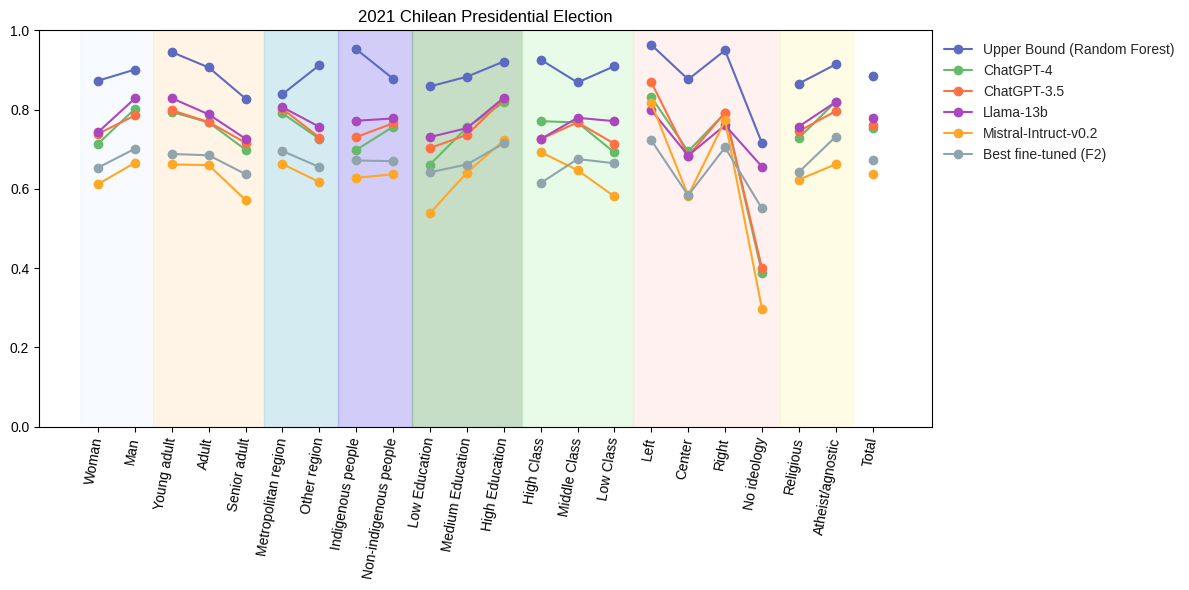

In [52]:
# Colors for each model
modelos_colores = {
    "Upper Bound (Random Forest)": "#5c6bc0",
    "ChatGPT-4": "#66bb6a",
    "ChatGPT-3.5": "#ff7043",
    "Llama-13b": "#ab47bc",
    "Mistral-Intruct-v0.2": "#ffa726",
    "T-zero": "#f48fb1",
    "Best fine-tuned (F2)": "#90a4ae",
    "Embedding + RandomForest": "#1e88e5"
}

modelos = [results_rf, gpt4_json_metrics, gpt3_json_metrics, llama_json_metrics, mistral_json_metrics, f_1_metrics]
modelos_nombres = ["Upper Bound (Random Forest)", "ChatGPT-4", "ChatGPT-3.5", "Llama-13b", "Mistral-Intruct-v0.2", "Best fine-tuned (F2)", "Embedding + RandomForest"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "2021 Chilean Presidential Election")

## Performance comparison between prompt variation for each model

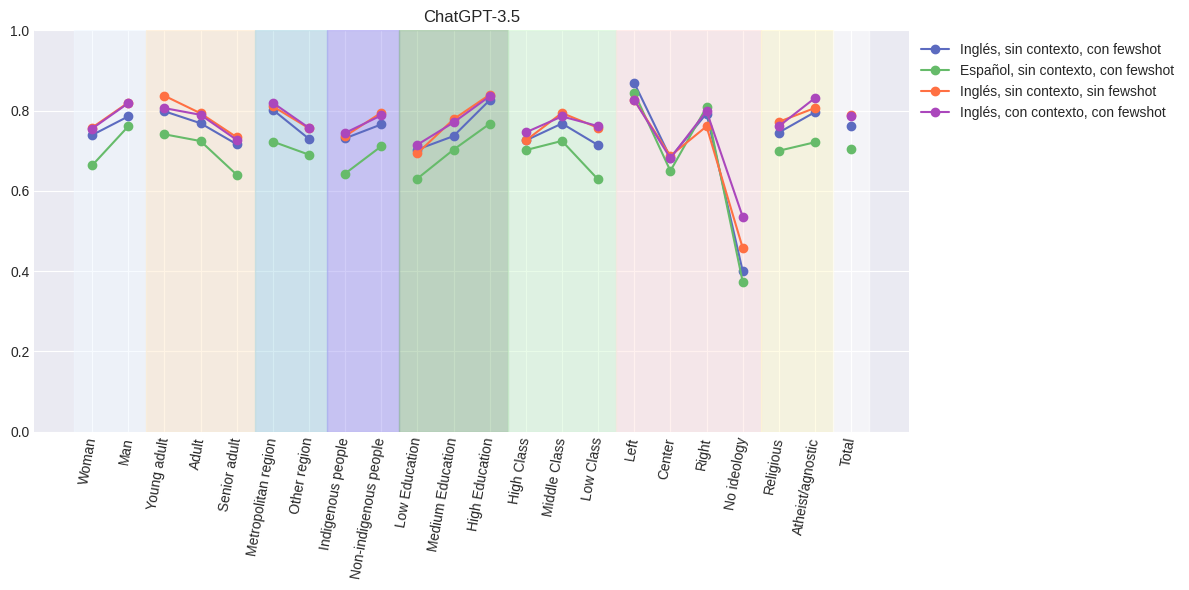

In [53]:
# Colores para cada modelo
modelos_colores = {
    "Inglés, sin contexto, con fewshot": "#5c6bc0",
    "Español, sin contexto, con fewshot": "#66bb6a",
    "Inglés, sin contexto, sin fewshot": "#ff7043",
    "Inglés, con contexto, con fewshot": "#ab47bc",
}

modelos = [gpt3_json_metrics, gpt3_json_esp_metrics, gpt_json_metrics_0, gpt3_json_context_metrics]
modelos_nombres = ["Inglés, sin contexto, con fewshot", "Español, sin contexto, con fewshot", "Inglés, sin contexto, sin fewshot", "Inglés, con contexto, con fewshot"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "ChatGPT-3.5")

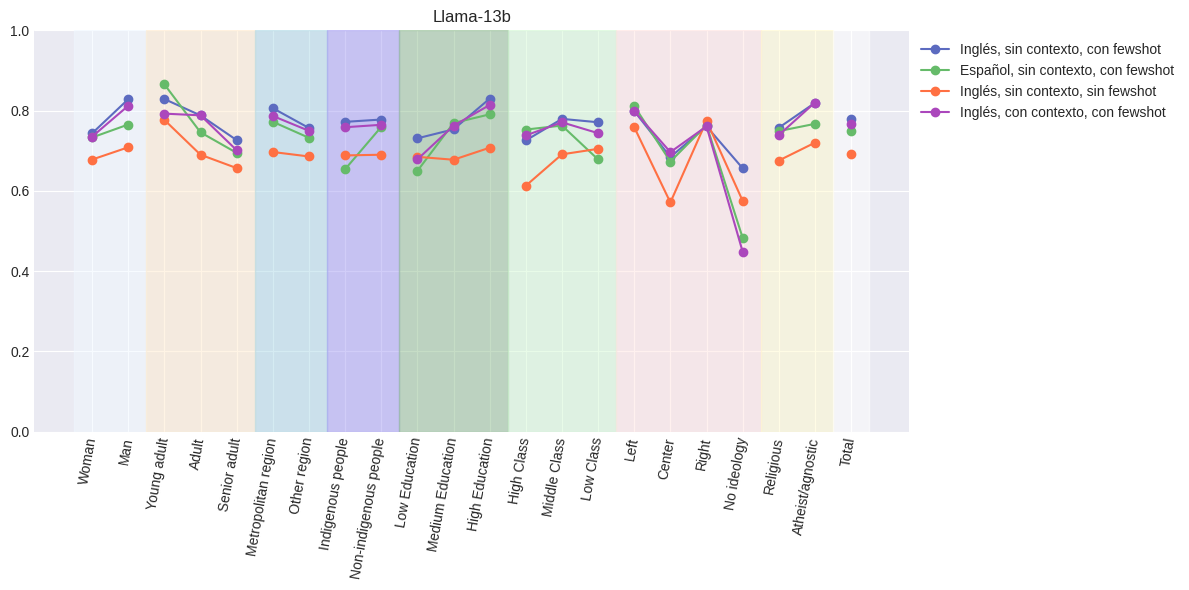

In [54]:
# Colores para cada modelo
modelos_colores = {
    "Inglés, sin contexto, con fewshot": "#5c6bc0",  # Azul suave
    "Español, sin contexto, con fewshot": "#66bb6a",               # Verde suave
    "Inglés, sin contexto, sin fewshot": "#ff7043", # Naranja suave
    "Inglés, con contexto, con fewshot": "#ab47bc",                 # Morado suave
}

modelos = [llama_json_metrics, llama_json_esp_metrics, llama_json_metrics_0, llama_json_context_metrics]
modelos_nombres = ["Inglés, sin contexto, con fewshot", "Español, sin contexto, con fewshot", "Inglés, sin contexto, sin fewshot", "Inglés, con contexto, con fewshot"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Llama-13b")

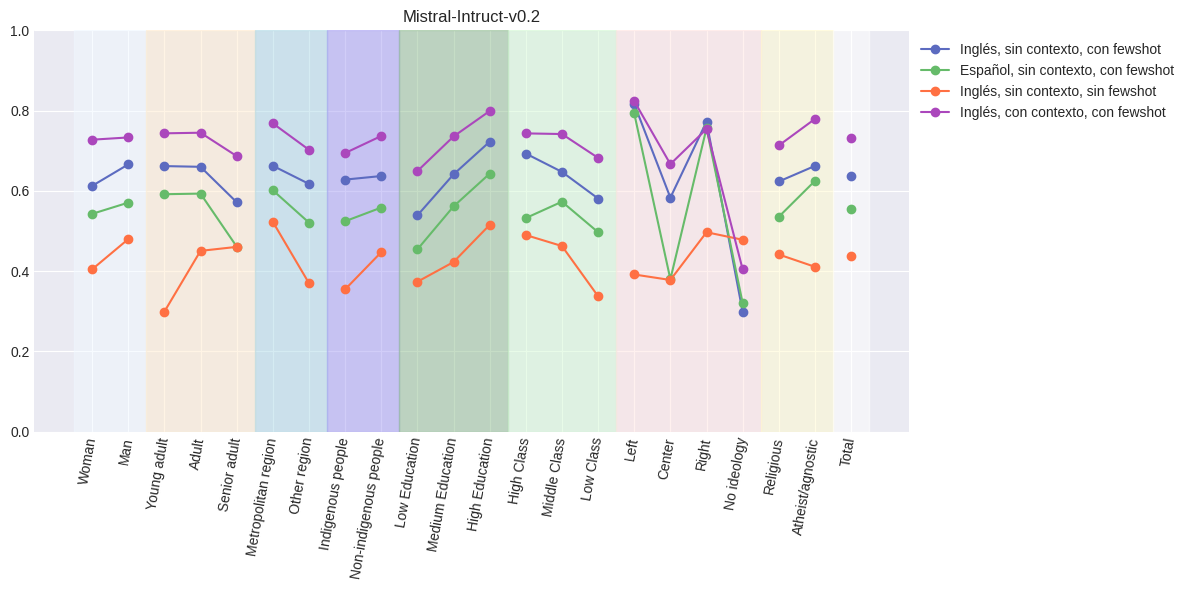

In [55]:
# Colores para cada modelo
modelos_colores = {
    "Inglés, sin contexto, con fewshot": "#5c6bc0",  # Azul suave
    "Español, sin contexto, con fewshot": "#66bb6a",               # Verde suave
    "Inglés, sin contexto, sin fewshot": "#ff7043", # Naranja suave
    "Inglés, con contexto, con fewshot": "#ab47bc",                 # Morado suave
}

modelos = [mistral_json_metrics, mistral_json_esp_metrics, mistral_json_metrics_0, mistral_json_context_metrics]
modelos_nombres = ["Inglés, sin contexto, con fewshot", "Español, sin contexto, con fewshot", "Inglés, sin contexto, sin fewshot", "Inglés, con contexto, con fewshot"]
sociodemographic_line_plot(modelos, modelos_colores, modelos_nombres, "Mistral-Intruct-v0.2")

# Bar PLots

## Prompt Designs Comparison


### Metrics Tables

In [56]:
llama_table_p = metrics_by_prompt_table([llama_text_metrics, llama_list_metrics, llama_json_metrics, llama_text_with_preamble_metrics, llama_refpaper_metrics], "Llama-13b")
llama_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Llama-13b,Text,0.578788,0.750519,0.653560
1,Llama-13b,List,0.583333,0.747286,0.655209
2,Llama-13b,Chain of thought,0.687879,0.897708,0.778909
3,Llama-13b,Text with Preamble,0.671212,0.931018,0.780051
4,Llama-13b,Completion,0.593939,0.719108,0.650558


In [57]:
mistral_table_p = metrics_by_prompt_table([mistral_text_metrics, mistral_list_metrics, mistral_json_metrics, mistral_text_with_preamble_metrics, mistral_refpaper_metrics], "Mistral")
mistral_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Mistral,Text,0.583333,0.756268,0.658638
1,Mistral,List,0.596970,0.746748,0.663511
2,Mistral,Chain of thought,0.537879,0.781805,0.637299
3,Mistral,Text with Preamble,0.575758,0.793547,0.667333
4,Mistral,Completion,0.518182,0.626690,0.567294


In [58]:
t0_table_p = metrics_by_prompt_table([t0_text_metrics, t0_list_metrics, t0_json_metrics, t0_text_with_preamble_metrics, t0_refpaper_metrics], "T-zero", names_list=["Text-template", "List-Template", "Estructura JSON", "Diseñado por autores", "Prompt del paper"])
t0_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,T-zero,Text-template,0.240909,0.360170,0.288708
1,T-zero,List-Template,0.331818,0.381486,0.354923
2,T-zero,Estructura JSON,0.353030,0.336857,0.344754
3,T-zero,Diseñado por autores,0.396970,0.521589,0.450826
4,T-zero,Prompt del paper,0.236364,0.355950,0.284085


In [59]:
chatgpt_table_p = metrics_by_prompt_table([gpt3_list_metrics, gpt3_text_metrics, gpt3_json_metrics, gpt3_text_with_preamble_metrics, gpt3_refpaper_metrics], "GPT3.5")
chatgpt_table_p

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,GPT3.5,Text,0.639394,0.931917,0.758427
1,GPT3.5,List,0.621212,0.870783,0.725124
2,GPT3.5,Chain of thought,0.640909,0.937673,0.761396
3,GPT3.5,Text with Preamble,0.557576,0.795129,0.655494
4,GPT3.5,Completion,0.610606,0.739772,0.669012


### Plots

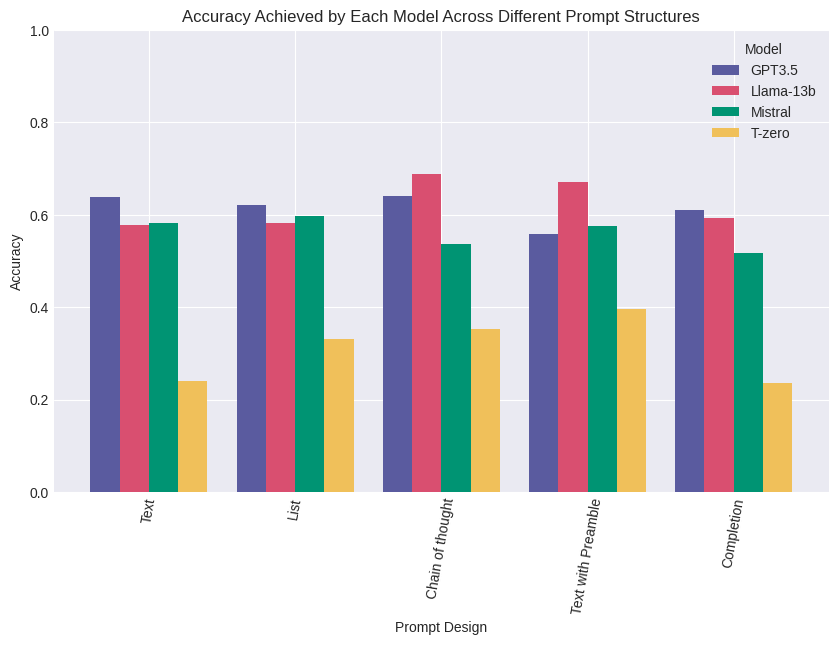

In [60]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([chatgpt_table_p, llama_table_p, mistral_table_p, t0_table_p], "Accuracy Achieved by Each Model Across Different Prompt Structures",  "Prompt Design")

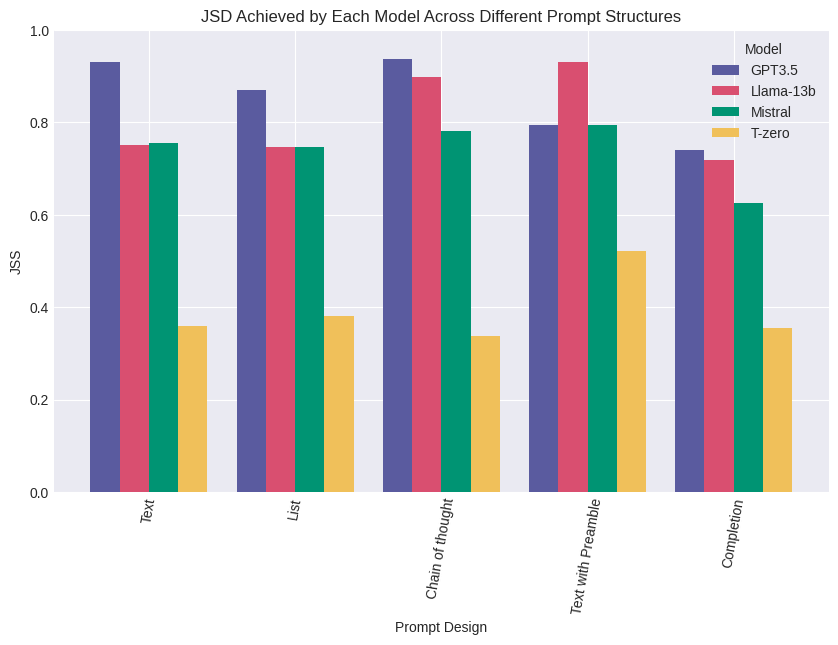

In [61]:
prompting_bar([chatgpt_table_p, llama_table_p, mistral_table_p, t0_table_p ], "JSD Achieved by Each Model Across Different Prompt Structures", "Prompt Design", metric="JSS")

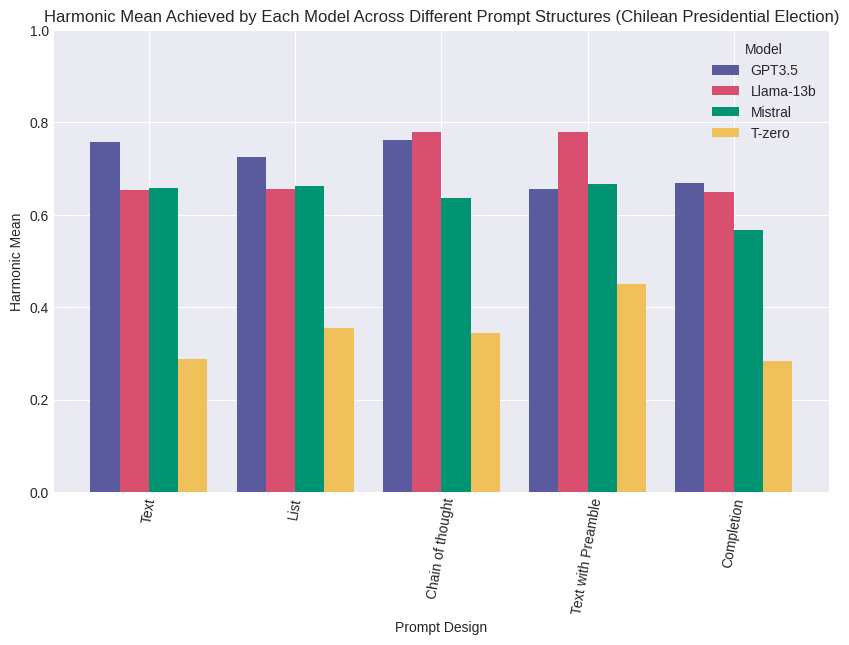

In [62]:
prompting_bar([chatgpt_table_p, llama_table_p, mistral_table_p, t0_table_p], "Harmonic Mean Achieved by Each Model Across Different Prompt Structures (Chilean Presidential Election)", "Prompt Design", metric="Harmonic Mean")

## Context Prompts Comparison

### Matrics Tables

In [63]:
gpt_contexto_table = metrics_by_prompt_table([gpt3_json_context_metrics, gpt3_json_metrics], "GPT-3.5-turbo", names_list=["Con contexto", "Sin contexto"])
gpt_contexto_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,GPT-3.5-turbo,Con contexto,0.662121,0.967938,0.786342
1,GPT-3.5-turbo,Sin contexto,0.640909,0.937673,0.761396


In [64]:
llama_contexto_table = metrics_by_prompt_table([llama_json_context_metrics, llama_json_metrics], "Llama-13b", names_list=["Con contexto", "Sin contexto"])
llama_contexto_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Llama-13b,Con contexto,0.657576,0.920838,0.767252
1,Llama-13b,Sin contexto,0.687879,0.897708,0.778909


In [65]:
mistral_contexto_table = metrics_by_prompt_table([mistral_json_context_metrics, mistral_json_metrics], "Mistral-v0.2", names_list=["Con contexto", "Sin contexto"])
mistral_contexto_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Mistral-v0.2,Con contexto,0.619697,0.894417,0.732135
1,Mistral-v0.2,Sin contexto,0.537879,0.781805,0.637299


### Plots

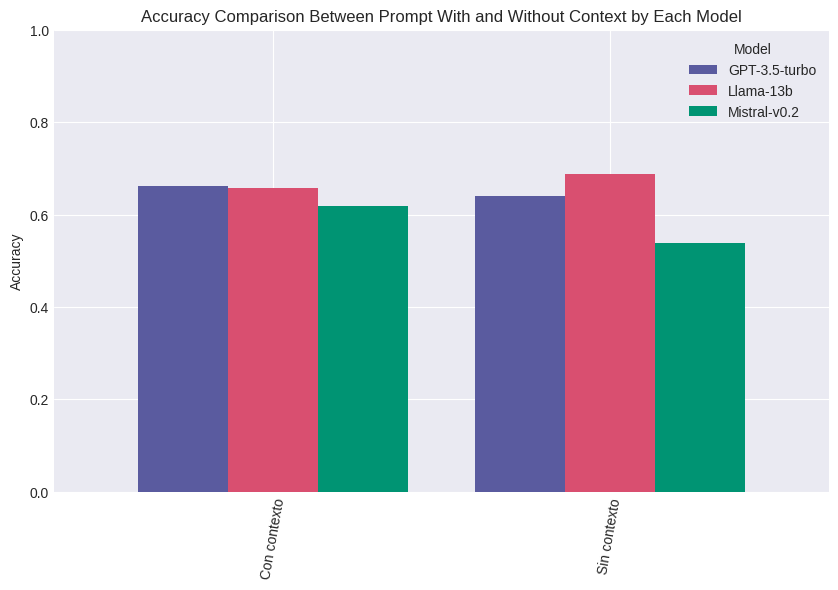

In [66]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_contexto_table, llama_contexto_table, mistral_contexto_table],"Accuracy Comparison Between Prompt With and Without Context by Each Model", "")

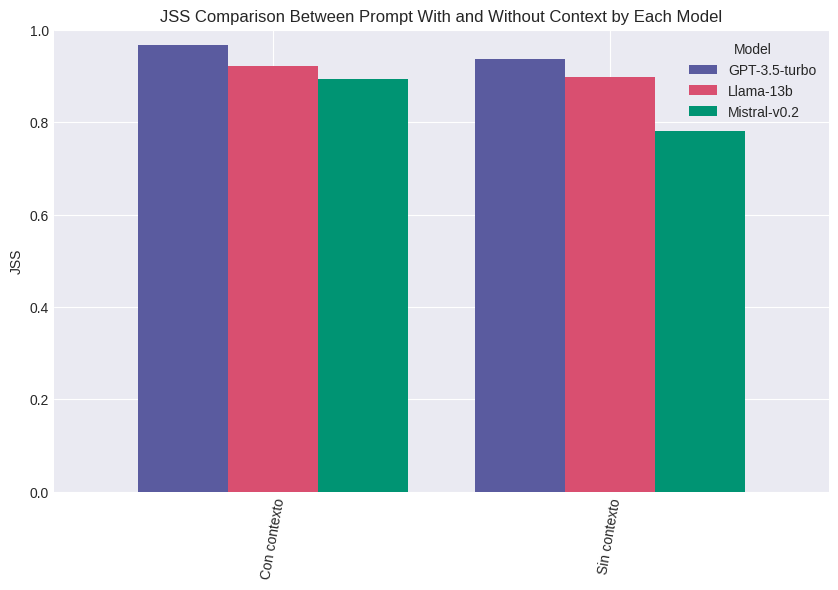

In [67]:
prompting_bar([gpt_contexto_table, llama_contexto_table, mistral_contexto_table],"JSS Comparison Between Prompt With and Without Context by Each Model","", metric="JSS")

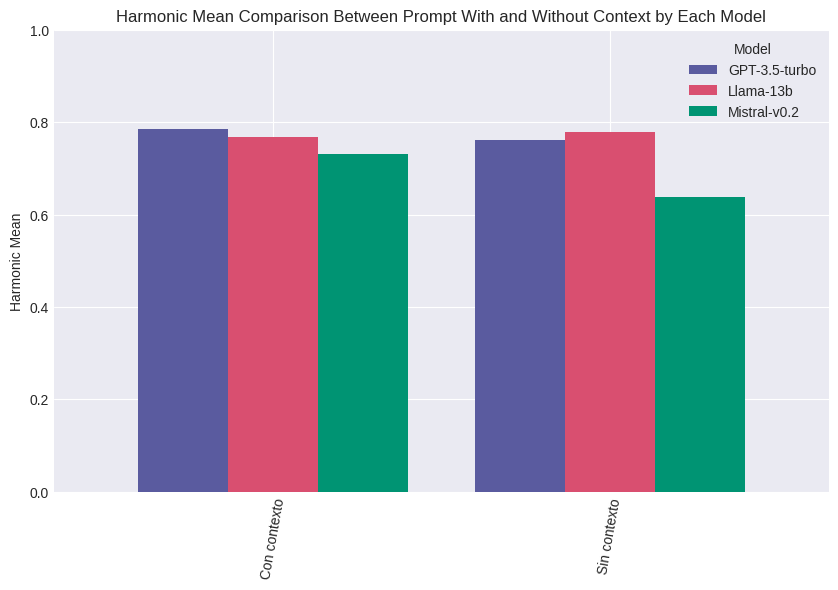

In [68]:
prompting_bar([gpt_contexto_table, llama_contexto_table, mistral_contexto_table],"Harmonic Mean Comparison Between Prompt With and Without Context by Each Model", "", metric="Harmonic Mean")

## Prompting Sin fewshot


### Metrics Tables

In [69]:
names_list=["English, without context, with fewshot", "Spanish, without context, with fewshot", "English, without context, without fewshot", "English, with context, with fewshot"]

In [70]:
gpt_0_table = metrics_by_prompt_table([gpt3_json_metrics, gpt3_json_esp_metrics, gpt_json_metrics_0, gpt3_json_context_metrics], "GPT-3.5-turbo", names_list = names_list)
gpt_0_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,GPT-3.5-turbo,"English, without context, with fewshot",0.640909,0.937673,0.761396
1,GPT-3.5-turbo,"Spanish, without context, with fewshot",0.613636,0.826815,0.704451
2,GPT-3.5-turbo,"English, without context, without fewshot",0.657576,0.990007,0.790254
3,GPT-3.5-turbo,"English, with context, with fewshot",0.662121,0.967938,0.786342


In [71]:
llama_0_table = metrics_by_prompt_table([llama_json_metrics, llama_json_esp_metrics, llama_json_metrics_0, llama_json_context_metrics], "Llama-13b", names_list=names_list)
llama_0_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Llama-13b,"English, without context, with fewshot",0.687879,0.897708,0.778909
1,Llama-13b,"Spanish, without context, with fewshot",0.642424,0.899779,0.749629
2,Llama-13b,"English, without context, without fewshot",0.669697,0.713322,0.690821
3,Llama-13b,"English, with context, with fewshot",0.657576,0.920838,0.767252


In [72]:
mistral_0_table = metrics_by_prompt_table([mistral_json_metrics, mistral_json_esp_metrics, mistral_json_metrics_0, mistral_json_context_metrics], "Mistral", names_list=names_list)
mistral_0_table

,Model,Prompting,Accuracy,JSS,Harmonic Mean
0,Mistral,"English, without context, with fewshot",0.537879,0.781805,0.637299
1,Mistral,"Spanish, without context, with fewshot",0.478788,0.661800,0.555611
2,Mistral,"English, without context, without fewshot",0.353030,0.573066,0.436909
3,Mistral,"English, with context, with fewshot",0.619697,0.894417,0.732135


### Plots

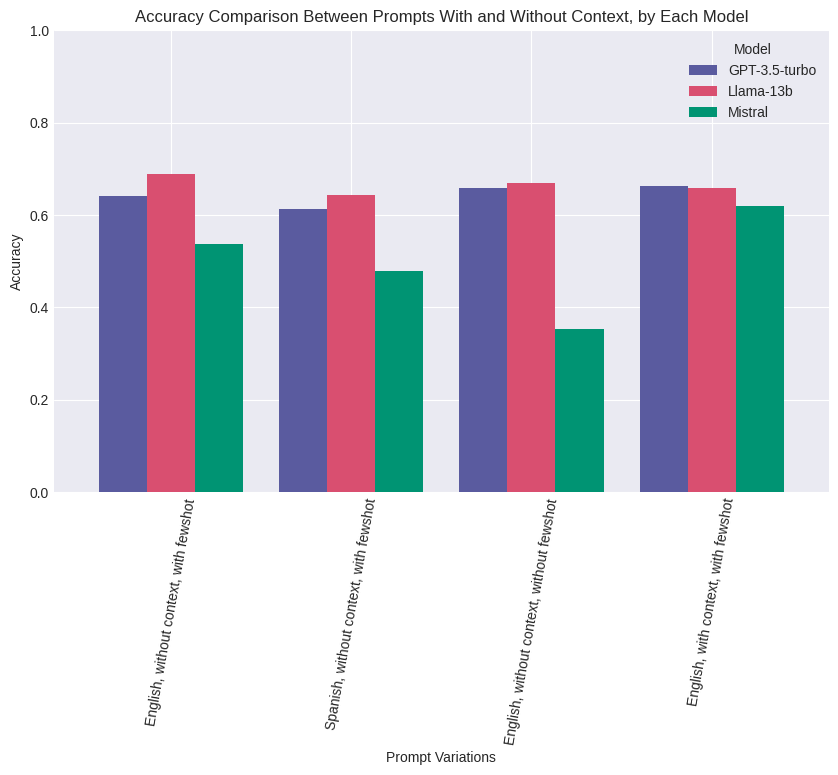

In [73]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_0_table, llama_0_table, mistral_0_table], "Accuracy Comparison Between Prompts With and Without Context, by Each Model", "Prompt Variations", metric = "Accuracy")

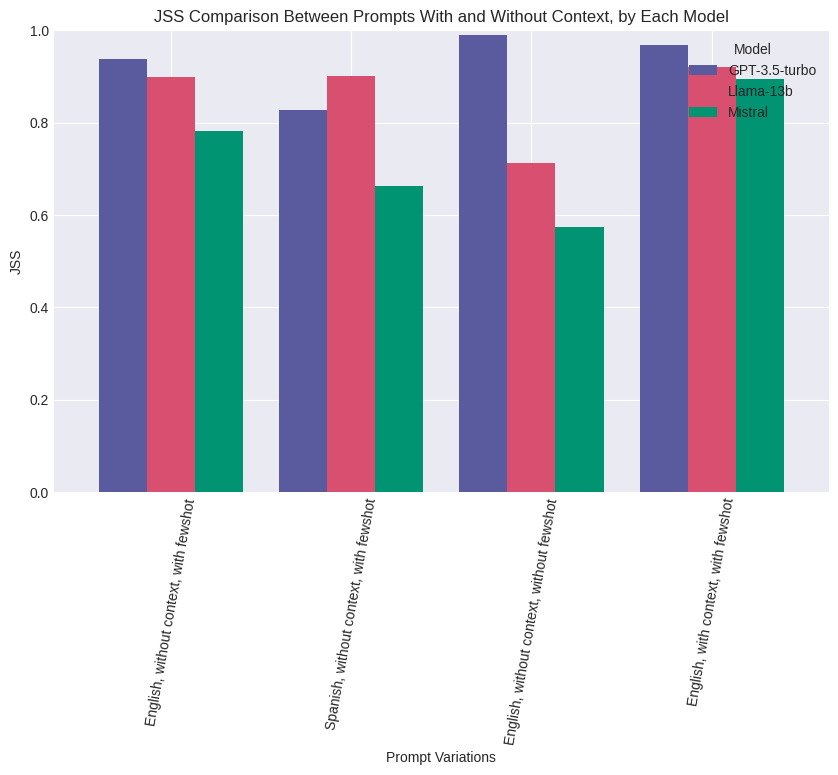

In [74]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_0_table, llama_0_table, mistral_0_table], "JSS Comparison Between Prompts With and Without Context, by Each Model", "Prompt Variations", metric = "JSS")

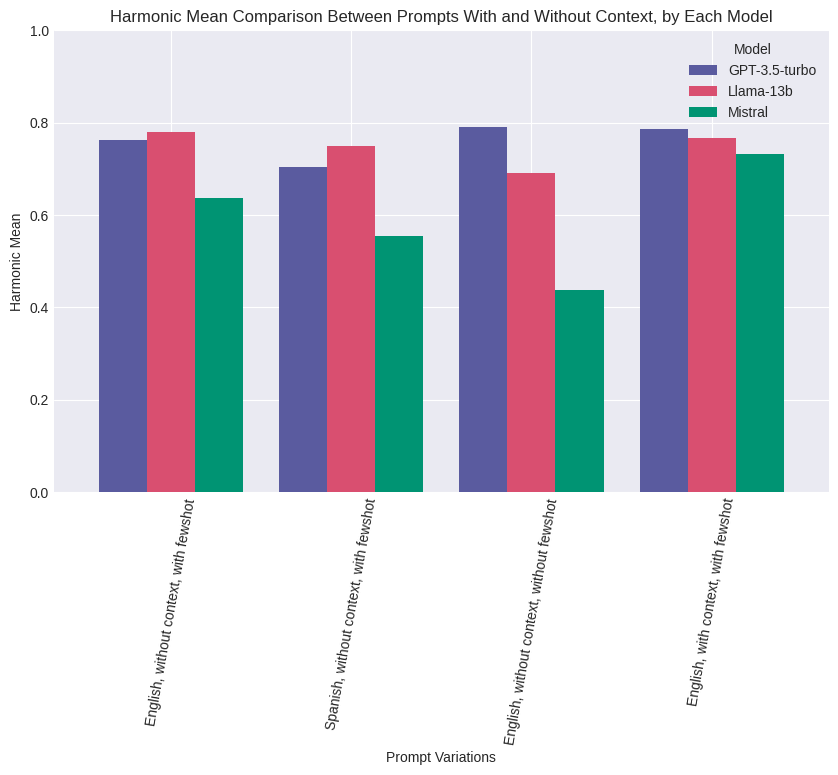

In [75]:
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')
prompting_bar([gpt_0_table, llama_0_table, mistral_0_table], "Harmonic Mean Comparison Between Prompts With and Without Context, by Each Model", "Prompt Variations", metric = "Harmonic Mean")

## Votes Distribution per Sociodemographic Group

In [76]:
df = pd.read_csv(results_route +"exp_inputs_filtrado.csv")

In [77]:
quantities_per_option_per_group(df, "elec_pres_144_a", ["Boric", "Kast", "Null"])

,Group,Boric,Kast,Null
0,Woman,229,124,32
1,Man,153,109,13
2,Young adult,60,16,2
3,Adult,222,141,24
4,Senior adult,100,76,19
5,Metropolitan region,169,100,19
6,Other region,213,133,26
7,Indigenous people,38,18,2
8,Non-indigenous people,342,213,43
9,Low Education,118,65,22


En el caso de GPT aumentan mucho los votos nulos y disminuyen los votos para Kast.

In [78]:
quantities_per_option_per_group(llama_json, "pred", ["Boric", "Kast", "Nulo"])

,Group,Boric,Kast,Nulo
0,Woman,270,105,10
1,Man,173,94,8
2,Young adult,59,19,0
3,Adult,263,113,11
4,Senior adult,121,67,7
5,Metropolitan region,195,86,7
6,Other region,248,113,11
7,Indigenous people,47,10,1
8,Non-indigenous people,394,188,16
9,Low Education,119,71,15


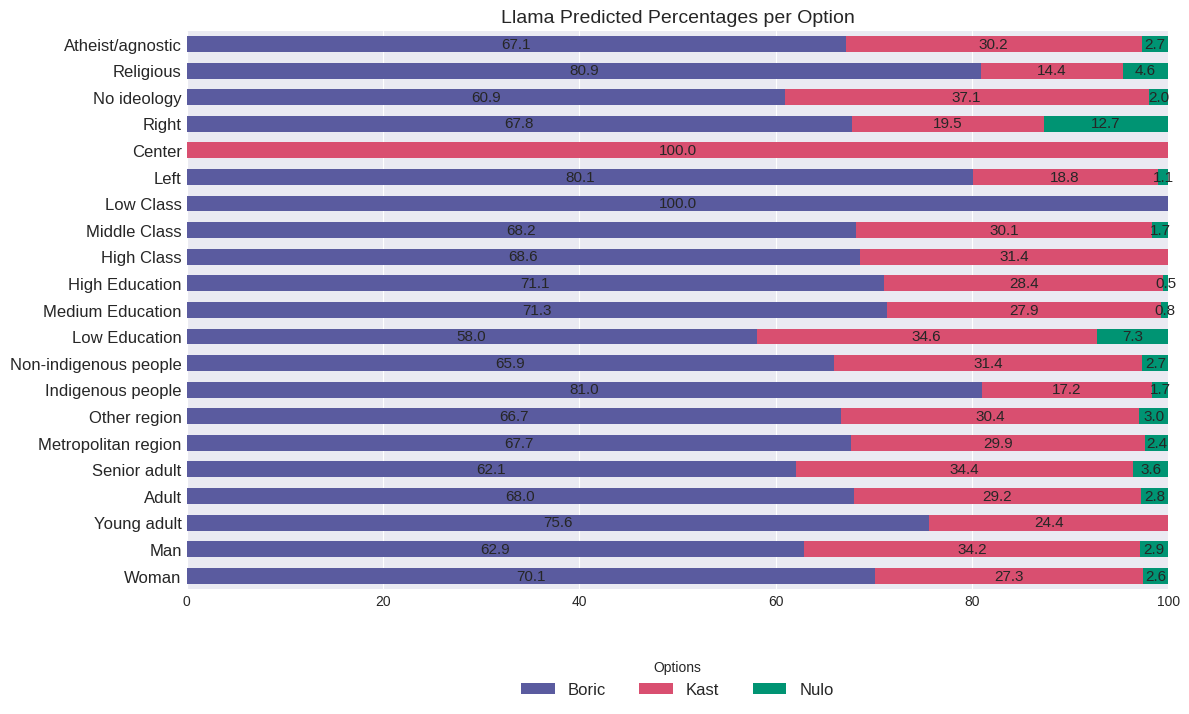

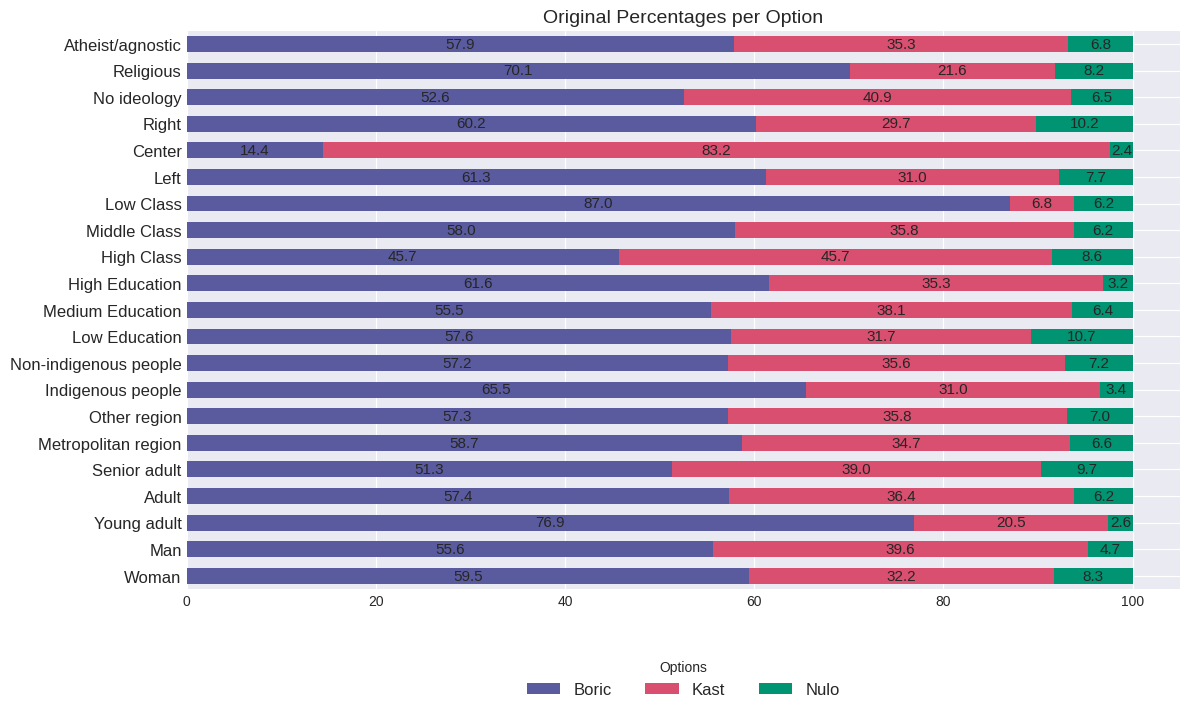

In [79]:
prop_llama = distribution_of_votes_per_group_graph(llama_json, "pred", ["Boric", "Kast", "Nulo"], 'Llama Predicted Percentages per Option')
prop_original = distribution_of_votes_per_group_graph(df, "elec_pres_144_a", ["Boric", "Kast", "Nulo"], 'Original Percentages per Option')



## Ablation Experiment
Results and graphs of ablation Experiment, using Llama-13b (the best model) and chain of thought prompt (best prompt)

In [80]:
llama_json_wpv = data_charger(results_route +"exp_inputs_filtrado.csv",  prompt_design_route +"presidential_chile_llama_cot_without_political_vars.jsonl", d)
llama_json_onlypol = data_charger(results_route +"exp_inputs_filtrado.csv", prompt_design_route +"presidential_chile_llama_cot_only_political_vars.jsonl", d)

In [81]:
df_llama13b_ablation = ablation_charger(results_route +"exp_inputs_filtrado.csv", prompt_design_route +"presidential_chile_llama_cot_ablation.jsonl", d, remove=None)
df_llama13b_ablation

,Unnamed: 0.1,Unnamed: 0,Column1,sexo,edad,nom_region,zona_u_r,gse,esc_nivel_1,info_enc_58,...,pred_gender,pred_age,pred_region,pred_indigenous,pred_gse,pred_scholarity,pred_religion,pred_ideology,pred_party,pred_interest
0,0,0,3,2,40,METROPOLITANA,1,3,3,2,...,2,2,2,2,2,2,2,2,2,2
1,2,2,8,2,54,VALPARAÍSO,1,3,6,2,...,1,1,1,1,1,1,1,1,1,1
2,5,5,15,2,39,MAULE,1,2,8,2,...,2,2,2,2,2,2,2,2,2,2
3,6,6,17,1,21,MAULE,1,2,7,2,...,2,2,2,2,2,2,2,1,2,2
4,7,7,18,2,19,METROPOLITANA,1,2,4,2,...,2,1,1,1,1,1,1,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,808,808,1429,2,25,VALPARAÍSO,1,3,6,1,...,1,1,1,1,1,1,1,1,1,1
656,809,809,1434,2,25,METROPOLITANA,1,1,8,2,...,2,2,2,2,2,2,2,1,2,2
657,810,810,1436,2,22,METROPOLITANA,1,4,7,2,...,1,1,1,1,1,1,1,1,1,1
658,811,811,1439,1,54,ÑUBLE,1,1,8,2,...,1,1,1,1,1,1,1,2,1,1


In [82]:
df_llama13b_ablation.rename(columns={'pred_indigenous': 'pred_race'}, inplace=True)

In [83]:
df_list=[llama_json, llama_json_wpv, llama_json_onlypol]

Con llama13b se ve un comportamiento un poco más similar al de GPT, el rendimiento decae si no se incluyen las viariables políticas, o si solo se incluyen aquellas sin ninguna informacion sociodemográfica. Hay 2 variables: edad y escolaridad, que al quitarlas mejoran la precision pero nuevamente no logra superar el 5% por lo que no es un cambio considerable.

En este caso, no usar contexto hace empeorar la precisión en un 20%.

Nuevamente quitra la ideología genera una pérdida de precisión.

/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/drive/MyDrive/Results_Analysis/Notebooks/metrics.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df.loc[13] = [group_names[13]] + metrics_group_chile(df, "esc_nivel_1", "none", pred_variable, pred_column_name, n_options)
/content/dri

,model,acc,jss,h
0,All,0.687879,0.897708,0.778909
1,Without political variables,0.527273,0.880425,0.659551
2,Only political variables,0.598485,0.792322,0.681896
3,- gender,0.666667,0.914168,0.771042
4,- age,0.680303,0.883026,0.768521
5,- region,0.659091,0.922570,0.768885
6,- race,0.669697,0.922539,0.776043
7,- gse,0.663636,0.949655,0.781292
8,- scholarity,0.665152,0.938910,0.778670
9,- religion,0.640909,0.898819,0.748263


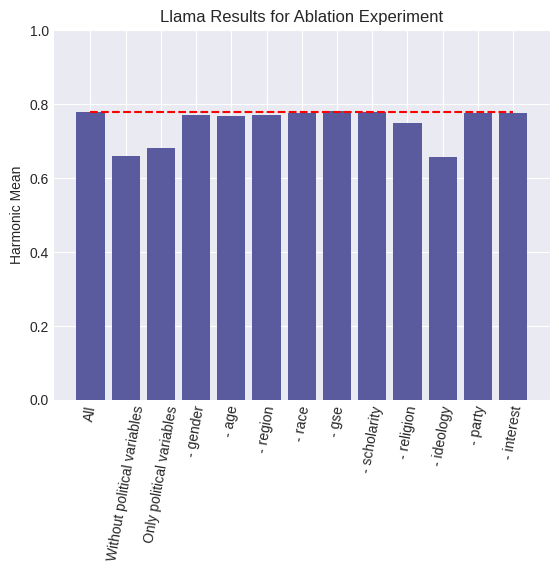

In [84]:
ablation_graph(df_list,df_llama13b_ablation, "elec_pres_144_a", 'Llama Results for Ablation Experiment', 'Harmonic Mean')